In [ ]:
from os import path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

from scipy.sparse import hstack

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import NMF
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV

from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import normalize
from sklearn.preprocessing import MaxAbsScaler


from sklearn.cluster import KMeans, HDBSCAN
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics.pairwise import cosine_similarity





In [ ]:
df = pd.read_csv("../../data/processed/glassdoor_reviews_cleaned.csv")


cols = ['summary', 'advice_to_management', 'review_pros','review_cons']
df[cols] = df[cols].fillna("")


In [3]:
df[cols].head(20)

,summary,advice_to_management,review_pros,review_cons
0,IT is Out of Control,Humble yourselves. Remember when you were comi...,"Salary was good for the position, but only bec...",Relentless pressure from the top. Constantly c...
1,Great Company to work with,Bring this great Company at par with similar g...,Great brand name. Top Management are consisten...,Work hours do not adhere to internationally ac...
2,Great,Good,Good and best and bestest best,Not bad and not bad and not bad
3,Vodafone is an Egotistical Company that only c...,You have some amazing staff members who are to...,Unfortunately there were no pros during my tim...,Retail stores are severely understaffed. The n...
4,"Great company, poor processes, high expectations",Handle customer escalations so BAMs can focus ...,Working with business owners or employees to s...,Sales expectations are unrealistic. Due to Cov...
5,Commercial Product Internship,,Very inclusive and helpful environment which m...,
6,Failing Product & Failing Management,,Decent work-life balance. Opportunity for lear...,Growth within the company is based on favoriti...
7,Regrettable Experience - A Workplace To Be War...,,Eye-opening: Teaches you exactly how a company...,Communication breakdown: An endemic lack of co...
8,HR is a joke,Get it together.,Most employees are great. Management will ask ...,HR and upper management do not support employe...
9,Worst company,,Although they are sweet initially at the time ...,No job security. Management shouts at employee...


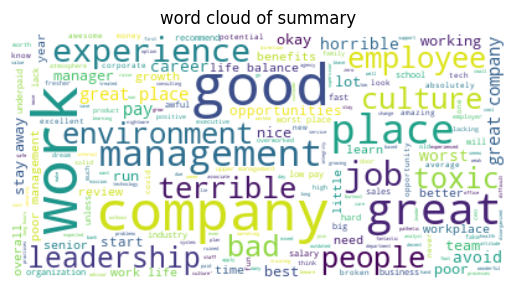

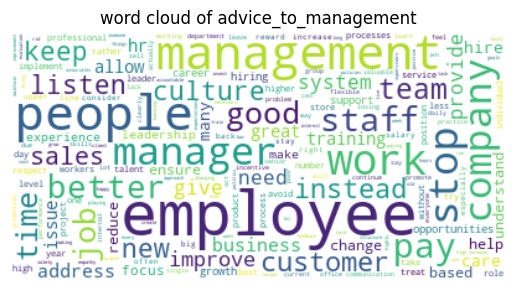

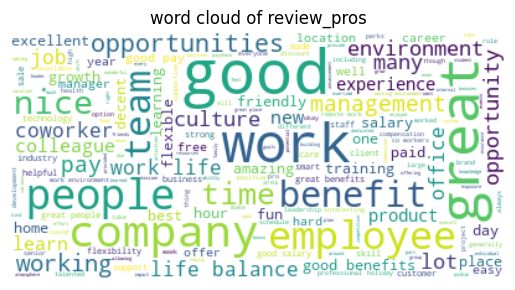

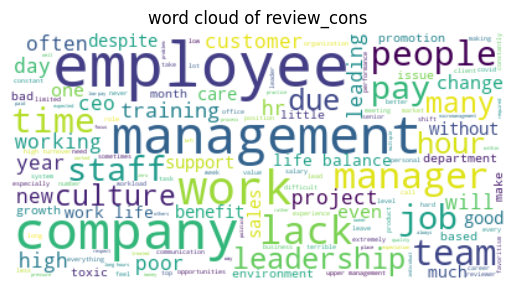

In [4]:
stopwords = STOPWORDS #.union(set(["bad","good", "great", "will", "company", "job", "work", "employee"]))


def plotWordCloudFromDF(df, column):
    text = ' '.join(df[column].astype(str).tolist()).lower()
    wordcloud = WordCloud(max_font_size=50, max_words=300, background_color="white", stopwords=stopwords).generate(text)
    plt.figure()
    plt.title(f"word cloud of {column}")
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

for col in ['summary', 'advice_to_management', 'review_pros','review_cons']:
    plotWordCloudFromDF(df, col)



In [5]:

vectorizer = TfidfVectorizer(
    sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english"
)

Xdata = vectorizer.fit_transform(df[cols[0]])
Xdata


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1627 stored elements and shape (1000, 100)>

In [6]:

# ---------------------------------------------------------
# 1. Data Preparation (Your exact code, mathematically patched)
# ---------------------------------------------------------
cols = ['summary', 'advice_to_management', 'review_pros', 'review_cons']

# CRITICAL FIX: Added min_df=5 and max_df=0.85 to filter out the noise tail 
# and meaningless corporate stop words (e.g., "company", "work").
vectorizers = [TfidfVectorizer(max_features=400, 
                               stop_words='english',
                               min_df=10,       # Word must appear in at least 5 reviews
                               max_df=0.6)    # Ignore words appearing in >85% of reviews
               for _ in cols]
sparse_matrices = []
all_feature_names = []

for col, vec in zip(cols, vectorizers):
    text_data = df[col].fillna('').astype(str)
    sparse_matrices.append(vec.fit_transform(text_data))
    
    vocab = vec.get_feature_names_out()
    prefixed_vocab = [f"{col}__{word}" for word in vocab]
    all_feature_names.extend(prefixed_vocab)

all_feature_names = np.array(all_feature_names) 
X_combined = hstack(sparse_matrices)
y = df['employee_length'].values
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

print(f"--- Data Structural Audit ---")
print(f"Total Combined Features: {X_combined.shape[1]}") 
print(f"Total Samples: {X_combined.shape[0]}")
print(f"First 10 Feature Names (Sample): {all_feature_names[:10]}")
# print(f"Middle Feature Names (Sample): {all_feature_names[300:310]}")


# Optional: Transform your entire dataset into the 15 Super Themes for predictive modeling
# X_super_themes = np.dot(W_train, kmeans.cluster_centers_.T) # Shape: (n_samples, 15)


scaler = MaxAbsScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


--- Data Structural Audit ---
Total Combined Features: 616
Total Samples: 1000
First 10 Feature Names (Sample): ['summary__avoid' 'summary__away' 'summary__bad' 'summary__balance'
 'summary__best' 'summary__career' 'summary__company' 'summary__culture'
 'summary__don' 'summary__employees']


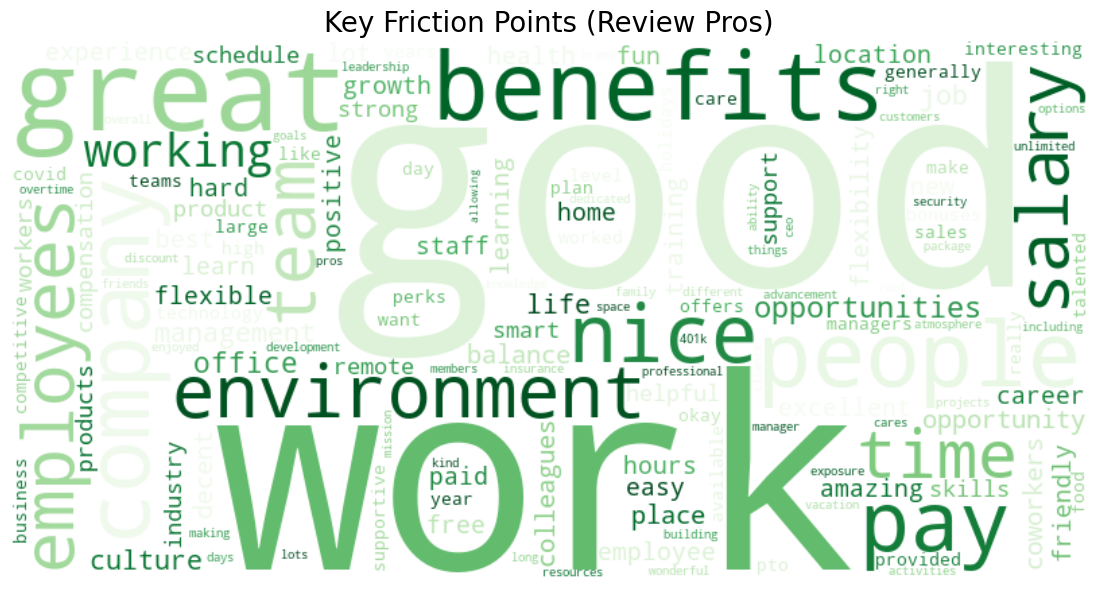

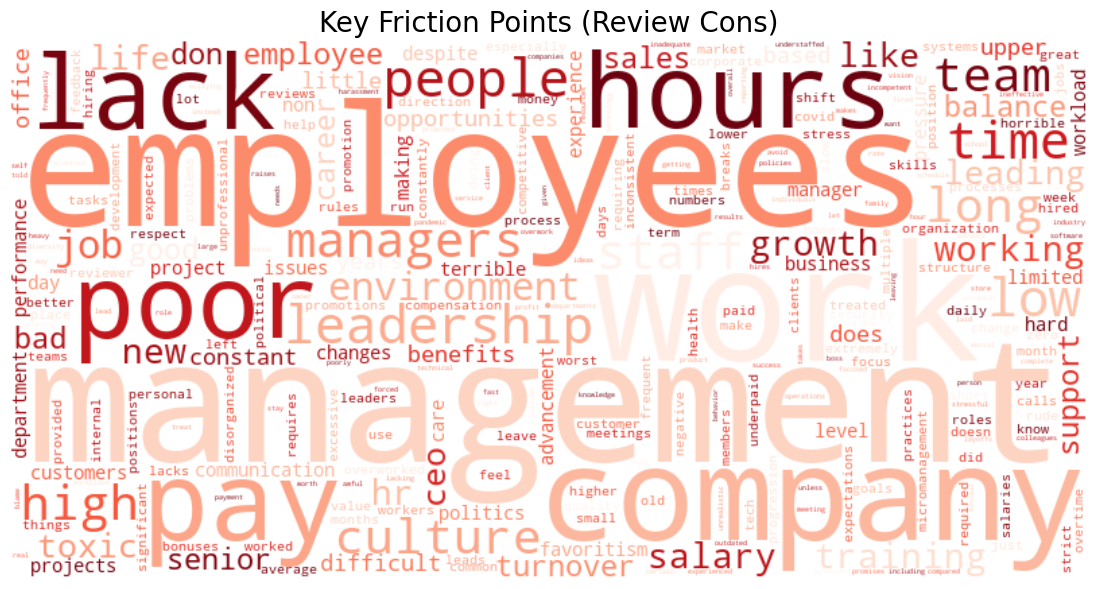

In [7]:


def get_column_word_weights(vectorizer, sparse_mat, prefix):
    feature_names = vectorizer.get_feature_names_out()
    col_indices = [i for i, name in enumerate(feature_names)]
    weights = sparse_mat.mean(axis=0).A1
    
    return {feature_names[i]: weights[i] for i in range(len(feature_names))}


pros_weights = get_column_word_weights(vectorizers[2], sparse_matrices[2], 'review_pros')

wc_pros = WordCloud(
    width=800, height=400, 
    background_color='white',
    colormap='Greens', 
    max_words=300
).generate_from_frequencies(pros_weights)

plt.figure(figsize=(15, 7))
plt.imshow(wc_pros, interpolation='bilinear')
plt.axis('off')
plt.title("Key Friction Points (Review Pros)", fontsize=20)
plt.show()


cons_weights = get_column_word_weights(vectorizers[3], sparse_matrices[3], 'review_cons')

wc_cons = WordCloud(
    width=800, height=400, 
    background_color='white',
    colormap='Reds', 
    max_words=300
).generate_from_frequencies(cons_weights)

plt.figure(figsize=(15, 7))
plt.imshow(wc_cons, interpolation='bilinear')
plt.axis('off')
plt.title("Key Friction Points (Review Cons)", fontsize=20)
plt.show()

In [8]:
# ---------------------------------------------------------
# 2. Model A: Cross-Validated Lasso (scikit-learn)
# ---------------------------------------------------------
print("Training LassoCV...")
lasso_cv_model = LassoCV(cv=10, random_state=42, n_jobs=-1)
lasso_cv_model.fit(X_train_scaled, y_train)

lasso_preds = lasso_cv_model.predict(X_test_scaled)
print(f"LassoCV MSE: {mean_squared_error(y_test, lasso_preds):.4f}")
print(f"Best Alpha found: {lasso_cv_model.alpha_:.4f}")



Training LassoCV...
LassoCV MSE: 12.4106
Best Alpha found: 0.0605


In [9]:
non_zero_count = np.sum(lasso_cv_model.coef_ != 0)
print(f"Nonzero-coeff {non_zero_count} / {X_train.shape[1]}")

coefs = lasso_cv_model.coef_

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Lasso Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])

Nonzero-coeff 3 / 616

--- Lasso Selected Factors ---
                Feature  Coefficient
2     review_pros__good     0.293580
0      summary__company    -0.149650
1  review_pros__balance     0.019471


In [10]:
ridge_cv = RidgeCV(cv=10)
ridge_cv.fit(X_train_scaled, y_train)


ridge_preds = ridge_cv.predict(X_test_scaled)
print(f"RidgeCV MSE: {mean_squared_error(y_test, ridge_preds):.4f}")
print(f"Best Alpha found: {ridge_cv.alpha_:.4f}")



non_zero_count = np.sum(ridge_cv.coef_ != 0)
print(f"Nonzero-coeff: {non_zero_count} / {X_train.shape[1]}")

import numpy as np
import pandas as pd

coefs = ridge_cv.coef_

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Ridge Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])

RidgeCV MSE: 12.4129
Best Alpha found: 10.0000
Nonzero-coeff: 616 / 616

--- Ridge Selected Factors ---
                          Feature  Coefficient
76     advice_to_management__work     1.776639
297            review_cons__early     1.730378
560           review_cons__taking     1.559450
222            review_pros__years     1.489288
85           review_pros__balance     1.480611
..                            ...          ...
27                 summary__place    -0.004904
320           review_cons__forced     0.004764
114         review_pros__employee     0.003505
381          review_cons__layoffs     0.003502
57   advice_to_management__issues     0.003302

[616 rows x 2 columns]


In [11]:



elastic_cv = ElasticNetCV(cv=10)
elastic_cv.fit(X_train_scaled, y_train)


elastic_preds = elastic_cv.predict(X_test_scaled)
print(f"Elastic CV MSE: {mean_squared_error(y_test, elastic_preds):.4f}")
print(f"Best Alpha found: {elastic_cv.alpha_:.4f}")



non_zero_count = np.sum(elastic_cv.coef_ != 0)
print(f"Nonzero-coeff: {non_zero_count} / {X_train.shape[1]}")

import numpy as np
import pandas as pd

coefs = ridge_cv.coef_

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Elastic Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])


Elastic CV MSE: 12.2610
Best Alpha found: 0.0524
Nonzero-coeff: 36 / 616

--- Elastic Selected Factors ---
                          Feature  Coefficient
76     advice_to_management__work     1.776639
297            review_cons__early     1.730378
560           review_cons__taking     1.559450
222            review_pros__years     1.489288
85           review_pros__balance     1.480611
..                            ...          ...
27                 summary__place    -0.004904
320           review_cons__forced     0.004764
114         review_pros__employee     0.003505
381          review_cons__layoffs     0.003502
57   advice_to_management__issues     0.003302

[616 rows x 2 columns]


In [12]:


# ---------------------------------------------------------
# 3. Model B: Neural Network (PyTorch)
# ---------------------------------------------------------
print("\nPreparing PyTorch Neural Network...")

# Trap: Convert sparse to dense. Watch your RAM here! 
X_train_tensor = torch.FloatTensor(X_train.toarray())
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.toarray())
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class TextRegressorNN(nn.Module):
    def __init__(self, input_dim):
        super(TextRegressorNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dimension = X_train_tensor.shape[1]
nn_model = TextRegressorNN(input_dim=input_dimension)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)


# Training Loop
epochs = 100
for epoch in range(epochs):
    nn_model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = nn_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

# Evaluation
nn_model.eval()
with torch.no_grad():
    nn_preds = nn_model(X_test_tensor)
    nn_mse = criterion(nn_preds, y_test_tensor)
    print(f"Neural Network MSE: {nn_mse.item():.4f}")


Preparing PyTorch Neural Network...
Epoch 10/100, Loss: 1.9240
Epoch 20/100, Loss: 1.6373
Epoch 30/100, Loss: 0.9780
Epoch 40/100, Loss: 1.4155
Epoch 50/100, Loss: 1.0658
Epoch 60/100, Loss: 1.0697
Epoch 70/100, Loss: 0.9583
Epoch 80/100, Loss: 1.2670
Epoch 90/100, Loss: 0.9341
Epoch 100/100, Loss: 0.7212
Neural Network MSE: 15.7747


In [13]:


# ---------------------------------------------------------
# 4. Feature Interpretation: Latent Semantic Analysis (LSA)
# ---------------------------------------------------------
print("\nPerforming Dimensionality Reduction (TruncatedSVD)...")
# We use TruncatedSVD instead of PCA to preserve the sparse matrix structure.
n_components = 355
svd_model = TruncatedSVD(n_components=n_components, random_state=42)
X_train_reduced = svd_model.fit_transform(X_train)

# Calculate explained variance
explained_variance = svd_model.explained_variance_ratio_.sum()
print(f"Total Explained Variance with {n_components} components: {explained_variance:.4f}")

def explain_component(svd_model, feature_names, component_idx, top_n=10):
    """
    Extracts the most influential words for a specific principal component.
    """
    # Get the weights (loadings) for the requested component
    component_weights = svd_model.components_[component_idx]
    
    # Sort indices by weight (ascending order)
    sorted_indices = np.argsort(component_weights)
    
    # Most negative weights (often representing one end of a semantic spectrum)
    bottom_words = feature_names[sorted_indices[:top_n]]
    bottom_weights = component_weights[sorted_indices[:top_n]]
    
    # Most positive weights (representing the other end of the spectrum)
    top_words = feature_names[sorted_indices[-top_n:]][::-1] # Reverse to get highest first
    top_weights = component_weights[sorted_indices[-top_n:]][::-1]
    
    print(f"\n--- Analysis of Component {component_idx} ---")
    print("Positive Drivers (Theme A):")
    for word, weight in zip(top_words, top_weights):
        print(f"  {word}: {weight:.4f}")
        
    print("\nNegative Drivers (Theme B):")
    for word, weight in zip(bottom_words, bottom_weights):
        print(f"  {word}: {weight:.4f}")

# Example: Explain the first 3 components to see what latent themes emerged
for i in range(3):
    explain_component(svd_model, all_feature_names, component_idx=i, top_n=5)


Performing Dimensionality Reduction (TruncatedSVD)...
Total Explained Variance with 355 components: 0.9484

--- Analysis of Component 0 ---
Positive Drivers (Theme A):
  summary__company: 0.2875
  review_pros__good: 0.2853
  summary__good: 0.2764
  summary__work: 0.2524
  review_pros__great: 0.2462

Negative Drivers (Theme B):
  review_cons__creating: 0.0034
  review_cons__professional: 0.0037
  review_cons__vision: 0.0038
  review_cons__period: 0.0042
  review_cons__late: 0.0043

--- Analysis of Component 1 ---
Positive Drivers (Theme A):
  summary__company: 0.8084
  summary__great: 0.1691
  review_pros__company: 0.1139
  review_pros__great: 0.0586
  review_cons__company: 0.0569

Negative Drivers (Theme B):
  summary__work: -0.3088
  summary__place: -0.2479
  review_pros__good: -0.1612
  review_pros__work: -0.1334
  summary__good: -0.1099

--- Analysis of Component 2 ---
Positive Drivers (Theme A):
  summary__good: 0.7701
  review_pros__good: 0.2120
  review_pros__benefits: 0.0871
  

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


In [14]:
# ---------------------------------------------------------
# 4. Feature Interpretation: Latent Semantic Analysis (LSA)
# ---------------------------------------------------------
print("\nPerforming Dimensionality Reduction (TruncatedSVD)...")
# We use TruncatedSVD instead of PCA to preserve the sparse matrix structure.
n_components = 410 



# Calculate explained variance
explained_variance = svd_model.explained_variance_ratio_.sum()
print(f"Total Explained Variance with {n_components} components: {explained_variance:.4f}")

def explain_component(svd_model, feature_names, component_idx, top_n=10):
    """
    Extracts the most influential words for a specific principal component.
    """
    # Get the weights (loadings) for the requested component
    component_weights = svd_model.components_[component_idx]
    
    # Sort indices by weight (ascending order)
    sorted_indices = np.argsort(component_weights)
    
    # Most negative weights (often representing one end of a semantic spectrum)
    bottom_words = feature_names[sorted_indices[:top_n]]
    bottom_weights = component_weights[sorted_indices[:top_n]]
    
    # Most positive weights (representing the other end of the spectrum)
    top_words = feature_names[sorted_indices[-top_n:]][::-1] # Reverse to get highest first
    top_weights = component_weights[sorted_indices[-top_n:]][::-1]
    
    print(f"\n--- Analysis of Component {component_idx} ---")
    print("Positive Drivers (Theme A):")
    for word, weight in zip(top_words, top_weights):
        print(f"  {word}: {weight:.4f}")
        
    print("\nNegative Drivers (Theme B):")
    for word, weight in zip(bottom_words, bottom_weights):
        print(f"  {word}: {weight:.4f}")

# Example: Explain the first 3 components to see what latent themes emerged
for i in range(3):
    explain_component(svd_model, all_feature_names, component_idx=i, top_n=5)


Performing Dimensionality Reduction (TruncatedSVD)...
Total Explained Variance with 410 components: 0.9484

--- Analysis of Component 0 ---
Positive Drivers (Theme A):
  summary__company: 0.2875
  review_pros__good: 0.2853
  summary__good: 0.2764
  summary__work: 0.2524
  review_pros__great: 0.2462

Negative Drivers (Theme B):
  review_cons__creating: 0.0034
  review_cons__professional: 0.0037
  review_cons__vision: 0.0038
  review_cons__period: 0.0042
  review_cons__late: 0.0043

--- Analysis of Component 1 ---
Positive Drivers (Theme A):
  summary__company: 0.8084
  summary__great: 0.1691
  review_pros__company: 0.1139
  review_pros__great: 0.0586
  review_cons__company: 0.0569

Negative Drivers (Theme B):
  summary__work: -0.3088
  summary__place: -0.2479
  review_pros__good: -0.1612
  review_pros__work: -0.1334
  summary__good: -0.1099

--- Analysis of Component 2 ---
Positive Drivers (Theme A):
  summary__good: 0.7701
  review_pros__good: 0.2120
  review_pros__benefits: 0.0871
  

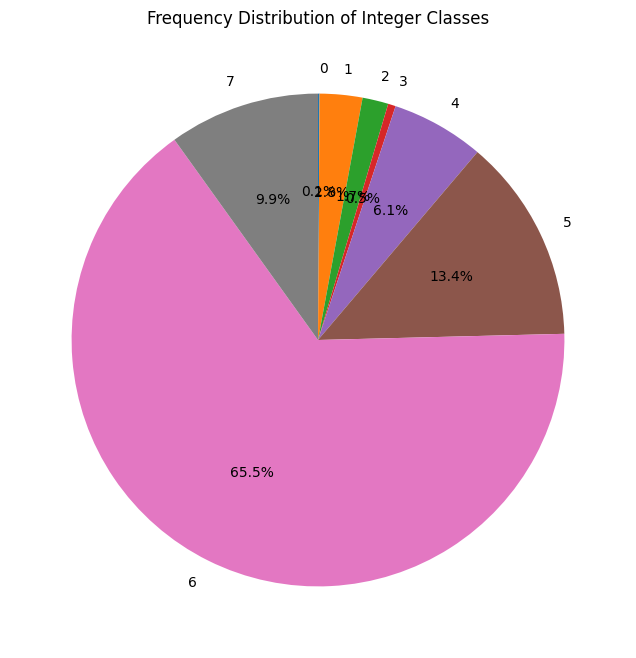

In [20]:

kmmodel = KMeans()
kmmodel.fit(X_combined)
y_grp = kmmodel.predict(X_combined)

# Vectorized frequency extraction
unique_labels, slice_sizes = np.unique(y_grp, return_counts=True)

# Rendering the composition
plt.figure(figsize=(8, 8))
plt.pie(slice_sizes, 
        labels=unique_labels, 
        autopct='%1.1f%%',   # Format percentages
        startangle=90,       # Rotate to start at the top
        counterclock=False)  # Render clockwise for better readability
plt.title('Frequency Distribution of Integer Classes')
plt.savefig('distribution_pie.png')

In [ ]:
kmmodel.predict(X_test)

array([7, 4, 4, 2, 4, 4, 3, 4, 4, 4, 4, 6, 4, 4, 4, 4, 7, 4, 4, 4, 4, 6,
       4, 7, 4, 4, 4, 4, 4, 3, 7, 4, 4, 4, 4, 4, 7, 4, 4, 4, 4, 4, 4, 7,
       4, 4, 6, 3, 7, 4, 4, 4, 4, 4, 4, 4, 7, 4, 4, 6, 4, 4, 4, 4, 4, 4,
       4, 5, 4, 4, 4, 4, 4, 4, 4, 2, 6, 5, 7, 6, 5, 4, 2, 2, 4, 4, 6, 4,
       4, 4, 6, 7, 4, 4, 4, 4, 7, 4, 7, 5, 1, 4, 4, 4, 7, 4, 4, 4, 7, 6,
       7, 4, 4, 4, 3, 6, 6, 4, 4, 4, 6, 4, 4, 2, 4, 4, 6, 1, 4, 2, 7, 4,
       4, 2, 4, 4, 6, 4, 4, 4, 4, 4, 7, 4, 4, 4, 4, 7, 4, 4, 4, 3, 6, 2,
       4, 1, 4, 6, 4, 3, 4, 7, 5, 4, 4, 4, 5, 2, 2, 7, 4, 2, 5, 4, 3, 4,
       4, 4, 2, 5, 4, 2, 4, 2, 4, 2, 4, 4, 4, 2, 2, 4, 2, 1, 7, 4, 4, 5,
       6, 4], dtype=int32)

Predicting Employee Type (Permanent/Temp) based on Sentimental Analysis of Reviews

Find Similar Companies 

In [21]:

# ---------------------------------------------------------
# 2. Topic Extraction (Using NMF for interpretable parts)
# ---------------------------------------------------------
# Even if you set n_components=100 here, NMF will yield pure topics.
# Let's assume you want to extract 100 granular micro-themes first.
n_topics = 400
nmf_model = NMF(n_components=n_topics, init='nndsvd', random_state=42, max_iter=500)
W_train = nmf_model.fit_transform(X_train)  # Document-Topic matrix
H_topics = nmf_model.components_           # Topic-Feature matrix (shape: 100, 4000)

H_norm = normalize(H_topics, norm='l1')

# ---------------------------------------------------------
# 3. Component Clustering (The solution to your 425-dimension nightmare)
# ---------------------------------------------------------
# Instead of reading 100 or 400 topics, we cluster the topics themselves based on their feature weights.
# We map the 100 granular components into 15 "Super Themes".
n_super_themes = 50
# kmeans = KMeans(n_clusters=n_super_themes, random_state=42, n_init=10)
# super_theme_labels = kmeans.fit_predict(H_topics)

# hdb = HDBSCAN(min_cluster_size=3, min_samples=5, store_centers='centroid', metric='cosine')
hdb = HDBSCAN(min_cluster_size=3, metric='cosine')
super_theme_labels = hdb.fit_predict(H_norm)

n_clusters_ = len(set(super_theme_labels)) - (1 if -1 in super_theme_labels else 0)
n_noise_ = list(super_theme_labels).count(-1)  

print(f"Num of Clusters: {n_clusters_}")
print(f"Noises: {n_noise_}")

# Build a readable dictionary mapping Super Themes to their sub-components and top words
topic_analysis = {}

for super_theme_id in range(n_super_themes):
    # Find which micro-components belong to this Super Theme
    component_indices = np.where(super_theme_labels == super_theme_id)[0]
    
    # Aggregate the feature weights across all components in this Super Theme
    aggregated_weights = np.mean(H_topics[component_indices], axis=0)
    
    # Get the top 7 driving features for this Super Theme
    top_feature_indices = aggregated_weights.argsort()[::-1][:7]
    top_features = all_feature_names[top_feature_indices]
    
    topic_analysis[f"Super_Theme_{super_theme_id}"] = {
        "Sub_Components_Contained": len(component_indices),
        "Driving_Features": list(top_features)
    }

# ---------------------------------------------------------
# 4. Display Results (Automated Labeling)
# ---------------------------------------------------------
for theme, data in topic_analysis.items():
    print(f"--- {theme} (Aggregates {data['Sub_Components_Contained']} micro-components) ---")
    print(f"Key Drivers: {', '.join(data['Driving_Features'])}\n")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


Num of Clusters: 2
Noises: 284
--- Super_Theme_0 (Aggregates 110 micro-components) ---
Key Drivers: review_pros__leadership, summary__life, review_cons__common, review_cons__seen, review_cons__20, review_cons__technology, review_cons__hour

--- Super_Theme_1 (Aggregates 6 micro-components) ---
Key Drivers: review_cons__inconsistent, advice_to_management__focus, review_cons__outside, review_cons__bullying, review_cons__term, review_cons__processes, review_cons__leaders

--- Super_Theme_2 (Aggregates 0 micro-components) ---
Key Drivers: review_cons__zero, review_pros__staff, review_pros__technology, review_pros__teams, review_pros__team, review_pros__talented, review_pros__supportive

--- Super_Theme_3 (Aggregates 0 micro-components) ---
Key Drivers: review_cons__zero, review_pros__staff, review_pros__technology, review_pros__teams, review_pros__team, review_pros__talented, review_pros__supportive

--- Super_Theme_4 (Aggregates 0 micro-components) ---
Key Drivers: review_cons__zero, revi

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [22]:

neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(H_norm) 
distances, _ = neigh.kneighbors(H_norm)

print(f"Avg Nearest Neibour: {np.mean(distances[:, 1:])}")
print(f"Max: {np.max(distances)}")

Avg Nearest Neibour: 0.7246982618383736
Max: 1.060260044030477


What workplace factors most strongly influence whether employees recommend their companies to others?